<a href="https://colab.research.google.com/github/annaBANNANA6/protein-interaction-network/blob/main/HINT_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **HINT Exploration Project**

[Pre-Exploration Notes](https://docs.google.com/document/d/1rV-KUo2NSnP1lT0BBUXkcC1NiRiVDxnyGEjknTZWpEk/edit?tab=t.npq3lirgfqla)

**Importing data**

*   `Uniprot_A` and `Uniprot_B`: standard identifiers for each protein in the pair
*   `Gene_A` and `Gene_B`
*   `pmid:method:quality:type`: each entry encodes PubMedID, experimental method, quality flag, interaction type together (seperated by colons)

--> if backed by both LC and HT, include both, separated by  '|' divider


*   `taxid`: NCBI taxonomy ID (confirms which orgnaism the interaction belongs to, human = 9606)
* `high_quality`: boolean confirming _hq values
* `in_pdb_source / PDB_IDs`: whether interaction has 3D structural evidence in Protein Data Bank, which structure ID if so





In [15]:
import pandas as pd
data = pd.read_csv("https://hint.yulab.org/download-raw/2024-06/HomoSapiens_binary_hq.txt", sep = "\t")

print(f"shape: {data.shape}") # should be 163435, 9 columns
print(f"\ncolumns: {data.columns}")

data.head()

shape: (163435, 9)

columns: Index(['Uniprot_A', 'Uniprot_B', 'Gene_A', 'Gene_B',
       'pmid:method:quality:type', 'taxid', 'high_quality', 'in_pdb_source',
       'PDB_IDs'],
      dtype='object')


,Uniprot_A,Uniprot_B,Gene_A,Gene_B,pmid:method:quality:type,taxid,high_quality,in_pdb_source,PDB_IDs
0,A0A024R2I8,F1D8Q5,NR1A2,NR2B1,15604093:0018:HT:binary|19211732:0018:LC:binar...,9606,True,False,NaN
1,A0A024R2I8,F1D8Q7,NR1A2,NR2B3,15604093:0018:HT:binary,9606,True,False,NaN
2,A0A024R2I8,O75376,NR1A2,NCOR1,12799135:0018:LC:binary|14985366:0096:LC:binar...,9606,True,False,NaN
3,A0A024R2I8,P12931,NR1A2,SRC,10454579:0096:LC:binary|14985366:0096:LC:binar...,9606,True,False,NaN
4,A0A024R2I8,P28702,NR1A2,RXRB,15604093:0018:HT:binary|9346901:0096:LC:binary,9606,True,False,NaN


**data orientation**

Is `taxid` uniform (all human)?
Is `high_quality` all True?
How many rows have null for PDB_Ids (which interactions have structural evidence)?

In [16]:
print(data['taxid'].unique()) # confirmed all human

print(data["high_quality"].unique()) # confirmed --> note to strip the space preceding this value

# data[data["PDB_IDs"].isna()]
print(f"# null rows for PDB_IDs: {(data["PDB_IDs"].isna()).sum()}")

[9606]
[ True]
# null rows for PDB_IDs: 149855


so the results: all human, all high quality, and 149855/163435 of rows are null for PDB_IDs, meaning that most are missing 3D strutural info

---

**data cleaning**
note that due to nature of HINT's purpose to remove erroneous and low-quality entries, there is not much tabular data cleaning checks for this (and already checked taxid and quality).

network specific cleaning checks:
*   **Self-loops** (does any rows have Uniprot_A == Uniprot_B? this would biologically that a protein interacting with itself, which does happen but might not want to keep depending on research question
*   **duplicate or reciprocal edges** are there rows where A,B appears once and B,A appears as separate row? check since PPIs lack direction, so these are the same



In [17]:
# self loop checks
self_loops = data[data["Uniprot_A"] == data["Uniprot_B"]]
print(f"Number of self loops / rows where A = B: {self_loops.shape[0]}")

# duplicate/reciprocal edges
# print(f"duplicates: {data.duplicated().sum()}")

# smaller in protein_1, larger in protein_2 (alphabetical comparison)
protein_1 = []
protein_2 = []

for index, row in data.iterrows(): # iterrow() - loop over df by row, each row is dict you index by column name
  a = row["Uniprot_A"]
  b = row["Uniprot_B"]

  if a < b:
    protein_1.append(a)
    protein_2.append(b)
  else:
    protein_1.append(b)
    protein_2.append(a)

# print(protein_1)
# print(protein_2)

# add sorted AB/BA columns back to DF and check duplicates
data["protein_1"] = protein_1
data["protein_2"] = protein_2
print(f"duplicates: {data.duplicated(subset = ["protein_1", "protein_2"]).sum()}")



Number of self loops / rows where A = B: 6034
duplicates: 0


In [18]:
# alternative way to check duplicates using np methods
import numpy as np
data["protein_1"] = np.minimum(data["Uniprot_A"], data["Uniprot_B"])
data["protein_2"] = np.maximum(data["Uniprot_A"], data["Uniprot_B"])
print(f"duplicates: {data.duplicated(subset = ["protein_1", "protein_2"]).sum()}")

duplicates: 0


**results**: 0 duplicate rows, but 6034 self loops, so protein interacting with itself (**homodimeritzation** which is mechanism where some transcription factors and enzymes ONLY funciton when two copies of themselves bind together. even with bio significance, think about mathematical significance --> drop to avoid ambiguity of adding degree to protein,inflating clustering ocefficient (loops create triangles AAB)

---

In [19]:
# dropping self loops for topological analysis
data = data.drop(self_loops.index)
data

,Uniprot_A,Uniprot_B,Gene_A,Gene_B,pmid:method:quality:type,taxid,high_quality,in_pdb_source,PDB_IDs,protein_1,protein_2
0,A0A024R2I8,F1D8Q5,NR1A2,NR2B1,15604093:0018:HT:binary|19211732:0018:LC:binar...,9606,True,False,NaN,A0A024R2I8,F1D8Q5
1,A0A024R2I8,F1D8Q7,NR1A2,NR2B3,15604093:0018:HT:binary,9606,True,False,NaN,A0A024R2I8,F1D8Q7
2,A0A024R2I8,O75376,NR1A2,NCOR1,12799135:0018:LC:binary|14985366:0096:LC:binar...,9606,True,False,NaN,A0A024R2I8,O75376
3,A0A024R2I8,P12931,NR1A2,SRC,10454579:0096:LC:binary|14985366:0096:LC:binar...,9606,True,False,NaN,A0A024R2I8,P12931
4,A0A024R2I8,P28702,NR1A2,RXRB,15604093:0018:HT:binary|9346901:0096:LC:binary,9606,True,False,NaN,A0A024R2I8,P28702
...,...,...,...,...,...,...,...,...,...,...,...
163361,Q9Y5Z9,Q9Y680,UBIAD1,FKBP7,32296183:0018:HT:binary|32296183:0397:HT:binar...,9606,True,False,NaN,Q9Y5Z9,Q9Y680
163383,Q9Y6D5,Q9Y6D6,ARFGEF2,ARFGEF1,10716990:0006:LC:binary|10716990:0071:LC:binar...,9606,True,False,NaN,Q9Y6D5,Q9Y6D6
163386,Q9Y6D9,Q9Y6W3,MAD1L1,CAPN7,32296183:0018:HT:binary|32296183:0397:HT:binar...,9606,True,False,NaN,Q9Y6D9,Q9Y6W3
163419,S6B2B6,S6C4R2,NaN,NaN,29760382:0114:LC:binary,9606,True,True,5W1K-O:T,S6B2B6,S6C4R2


**split pmid:method:quality:type** into four columns to explore. split by `|` first to give column with the list of study strings. then split by `:` to split the separate columns.

In [39]:
data["pmid:method:quality:type"].str.split(":", expand=True).shape
#split studies into a list for one column
studies = data["pmid:method:quality:type"].str.split("|")
studies.head()

# loop through each list of studies and split each study by :
quality = []
for row in studies:
  row_quality = []
  for study in row:
    parts_of_study = study.split(":")
    row_quality.append(parts_of_study[2])

  row_set = set(row_quality)

  quality.append(row_set)

print(quality[0:5])

# JUST REALIZED THAT TYPES IS ONLY BINARY DATA UGHHHHHH. WILL COMMENT OUT CO-COMPLEX LOOPS/FILTERING

[{'HT', 'LC'}, {'HT'}, {'LC'}, {'LC'}, {'HT', 'LC'}]

In [46]:
# descriptive stats (e.g. average number of studies per row)
studies.str.len().describe()

,pmid:method:quality:type
count,157401.000000
mean,3.155342
std,3.211830
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,312.000000


In [47]:
# figure out how many have study qualities with just one HT or LC vs both
one_count = 0
both_count = 0
for row in quality:
  if len(row) == 1:
    one_count += 1
  else:
    both_count += 1
print(f"One (HT or LC): {one_count}, Both (HT and LC): {both_count})")

# alt pandas way (use this instead!)
data["quality"] = quality
lengths_quality = data["quality"].apply(len)
lengths_quality.value_counts()


One (HT or LC): 151021, Both (HT and LC): 6380)
quality
1    151021
2      6380
Name: count, dtype: int64


**results/interpretation of quality column**: HINT interactions must be backed by at least 2 publications if LC, and just one if HT. most interactions have multiple studies but over 90% of them (as seen above) are backed by the same type (all LC or all HT) rathern than one HT backed by one LC confirming. seeing both HT and LC is definitely rarer, and a stronger confidence tier for subsets.

i'm going to make a `dual_evidence` boolean column (True for HT and LC, False for only one) to keep context on interaction confidence could be cool!

In [50]:
# dual_evidence column
data["dual_evidence"] = (lengths_quality == 2)
data["dual_evidence"].head()

,dual_evidence
0,True
1,False
2,False
3,False
4,True


**build network graph**: once edges become graph object, check for **isolated nodes** and **connected components**
*   **isolated node:** degree 0. consider that graph is being built from edge list itself so each node has at least on edge
*  **connected components**: component (cluster of nodes accessible from each other). usually get ONE big component with most proteins (small world effect) + long tail of smaller disconnected fragments (small clusters only interact w/ e/o

relevance: betwness centrality, shortest path length only WIHTIN compoment, so start analysis on giant component and note to do separately on smaller ones

**documentation**: https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html

https://pandas.pythonhumanities.com/04_02_graphing_networks_with_pandas.html



In [51]:
# imports
import networkx as nx
import matplotlib.pyplot as plt

target proteins in HINT human (examples):
* TP53 (cellular tumor antigen p53) big hub protein for DNA repair and cell death

**Task:** Use networkx from pandas edgelist to create Graph. Choose target protein to create subgraph and visualize.

https://networkx.org/documentation/stable/reference/drawing.html

https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html


In [53]:
# "networkx from pandas edgelist"" to create Graph
# edge_attr = True --> keeps experimental metadata onto edges
graph = nx.from_pandas_edgelist(data, source = "Uniprot_A", target = "Uniprot_B", edge_attr = True)

# subgraph for visualization
# ego_graph allows you to choose specific protein as "ego node"
target_protein = "P04637"  # uniprotID for TP53
subgraph = nx.ego_graph(graph, target_protein, radius = 1)

# NetworkX requires specific formatting (node1, node2, {attributes})
# graph.edges() returns pairs of connected nodes (Protein_A, Protein_B)
# adding edge.attr made NetworkX attaches to column values to each edge as a dictionary
print(subgraph.edges(data=True))

[('Q15291', 'P04637', {'Gene_A': 'TP53', 'Gene_B': 'RBBP5', 'pmid:method:quality:type': '15960975:0096:LC:binary|19433796:0007:LC:binary|23870121:0007:LC:binary|23870121:0096:LC:binary', 'taxid': 9606, 'high_quality': True, 'in_pdb_source': False, 'PDB_IDs': nan, 'protein_1': 'P04637', 'protein_2': 'Q15291', 'quality': {'LC'}, 'dual_evidence': False}), ('Q15291', 'P61964', {'Gene_A': 'WDR5', 'Gene_B': 'RBBP5', 'pmid:method:quality:type': '15960975:0007:LC:binary|16878130:0096:LC:binary|17041588:0006:LC:binary|17178841:0006:LC:binary|17500065:0006:LC:binary|17500065:0096:LC:binary|17925232:0006:LC:binary|19556245:0028:LC:binary|21220120:0065:LC:binary|21220120:0096:LC:binary|21220120:0114:LC:binary|31400120:0096:LC:binary|31400120:0114:LC:binary|31485071:0114:LC:binary|31544921:0096:LC:binary|31804488:0114:LC:binary|33961781:0007:LC:binary|34012049:0114:LC:binary|34928138:0114:LC:binary|36095189:0114:LC:binary|36408368:0055:LC:binary', 'taxid': 9606, 'high_quality': True, 'in_pdb_source

In [54]:
# spring_layout returns X,Y coordinates (position nodes) calculated using FR algorithm
# k = distance between nodes
position = nx.spring_layout(subgraph, k= 0.15, seed = 42)

In [55]:
# look at subgraph edge sample
first_edge = list(subgraph.edges(data=True))[0]
print("Your edge data looks like this:", first_edge)

Your edge data looks like this: ('Q15291', 'P04637', {'Gene_A': 'TP53', 'Gene_B': 'RBBP5', 'pmid:method:quality:type': '15960975:0096:LC:binary|19433796:0007:LC:binary|23870121:0007:LC:binary|23870121:0096:LC:binary', 'taxid': 9606, 'high_quality': True, 'in_pdb_source': False, 'PDB_IDs': nan, 'protein_1': 'P04637', 'protein_2': 'Q15291', 'quality': {'LC'}, 'dual_evidence': False})


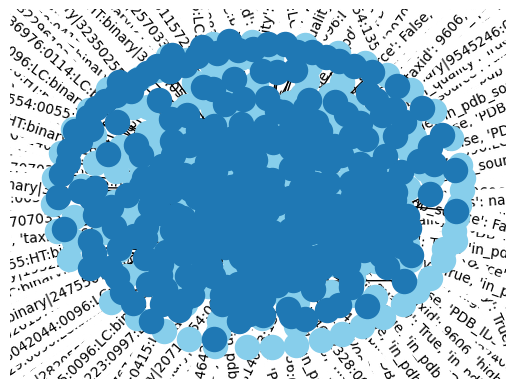

In [56]:
# __DISPLAY___!!!!!!!!!! yippeeeee

# draw nodes + specific node
nx.draw_networkx_nodes(subgraph, position, node_size = 300, node_color = "skyblue")
nx.draw_networkx_nodes(subgraph, position, nodelist = ["P04637"], node_size = 600, node_color = "blue")

# draw binary + complex edges (see previous commits to see binary vs co-complex filtering, not needed anymore though)
nx.draw_networkx_edges(subgraph, position, edgelist = subgraph.edges(), edge_color = "red", style = "solid")

nx.draw_networkx_edge_labels(subgraph, position)
nx.draw(subgraph)

wow how messy. improvements to the graph below to make it more visually understandable

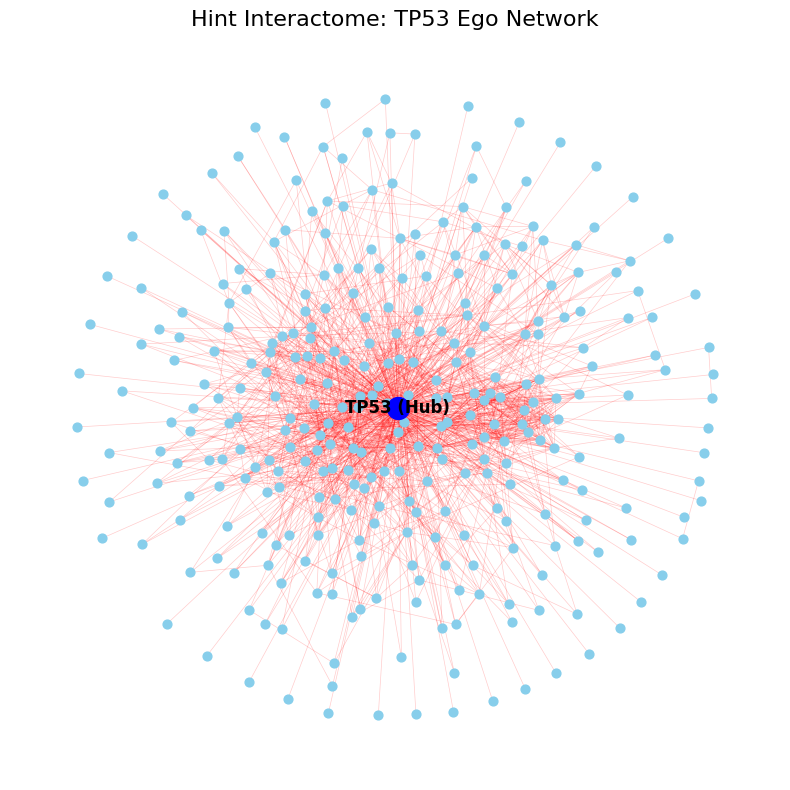

In [75]:
plt.figure(figsize= (8,8))

other_nodes = [node for node in subgraph.nodes() if node != "P04637"]
nx.draw_networkx_nodes(
    subgraph, position, nodelist = other_nodes, node_size =40, node_color = "skyblue"
)

nx.draw_networkx_nodes(subgraph, position, nodelist = ["P04637"], node_size = 250, node_color = "blue")

nx.draw_networkx_edges(subgraph, position, edgelist = subgraph.edges(), edge_color = "red", style = "solid", alpha = 0.2, width = 0.5)
# nx.draw_networkx_edges(subgraph, position, edgelist= complex_edges, edge_color = "green", style = "dashed", alpha = 0.2, width = 0.5)

# labels- this time only label the central hub/top 5 most important to avoid text explosion
labels = {"P04637": "TP53 (Hub)"}
nx.draw_networkx_labels(subgraph, position, labels=labels, font_size = 12, font_weight = "bold")

# clean edges
plt.title("Hint Interactome: TP53 Ego Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


gorgina. what a beauty so cool to see how connected this hub protein is (expected since it is a typical textbook hub protein). i wonder is it *so connected* because its biologically exceptional or due to the mere fact it has been studied so much? maybe something to think about later

---

**Connected components**: goal is to use NetworkX function to extract components from the WHOLE GRAPH (each item will be one component). Can see if the whole graph is one connected piece or nah.

use [networkx connected_components](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html)

How many components, size of each component (each compoennt is a collection of nodes use length)

In [87]:
# returns Python geneartor object with sets of nodes, each set is a connected component of undirected graph
components = nx.connected_components(graph)

components_list = list(components)
print(components_list)

print(f"Number of components in graph: {len(components_list)}")

# size of each component
comp_sizes = []
for comp in components_list:
  comp_sizes.append(len(comp))
print(f"Sizes of each component: {comp_sizes}")

# found network_x is_connected, returns True/False if network is connected
print(f"T/F if network is connected: {nx.is_connected(graph)}")

# percentage of total nodes for giant component
percent_nodes = (comp_sizes[0]/graph.number_of_nodes())*100
print(f"{percent_nodes}% of total nodes are represented by giant component")



[{'Q14146', 'Q9UC07', 'Q7Z5N4', 'O00762', 'P35916-2', 'Q05D60', 'Q8N9I5', 'P50402', 'Q9UIF7', 'P60953', 'Q96PX9', 'Q5JR59', 'O60499', 'A8K2R3', 'Q9H8S9-1', 'P37802', 'P19367', 'Q96MF7', 'Q5T619', 'Q9BZF9', 'Q92785', 'Q96I82', 'Q9NNX1', 'O75604', 'P15927', 'Q6ZVU3', 'Q03468', 'P29377', 'Q9UF11-1', 'Q68G74', 'Q9Y6E0', 'Q5VWJ9', 'Q9UPU5', 'O94808', 'P02745', 'Q8IYP9', 'Q8WU79', 'Q5VWK5', 'P27701', 'P32455', 'Q96CN5', 'Q99732', 'Q53FZ2-2', 'P51946', 'Q93077', 'Q9NRL2', 'Q8WYA6-3', 'O43422-1', 'Q53GG5', 'Q56P42', 'P57053', 'Q9Y5X9', 'Q9UPC5', 'Q9NS87', 'Q53GL7', 'Q8NAP8', 'Q99575', 'Q6ZPD9-2', 'P15498', 'Q70EL1-1', 'Q8NA54', 'Q9NVA2', 'O95257', 'P80303', 'Q99704', 'Q96RI1', 'Q8TCT9', 'P47804-2', 'Q9NZ52-1', 'Q6P1L6-3', 'Q9NV96-2', 'O15194-2', 'P61020', 'P32927-1', 'Q5JT82', 'Q96C12', 'Q9BV19', 'Q96T58', 'Q05066', 'Q8TBG9', 'Q8TBE0', 'Q8IUC4-1', 'Q9BV35', 'P22670', 'Q03135-1', 'P27448', 'P04844-1', 'Q9UK08', 'Q15306-1', 'Q86X55', 'P43626', 'Q9Y3E7', 'Q5T0N5', 'O00541', 'O43439', 'Q99460-1', 

**results**: there are 78 components. there is an obvious giant component / well connected one that has 20437 nodes (over 99% of all nodes), and the long tail of fragment components are all about 2-3 nodes.

**Isolated nodes**: these have degree 0. G.degree() returns an iterable, where each item pairs a node with its degree. should expect none to have degree 0

In [82]:
print(graph.degree())

zero_deg_counts = 0
for node in graph.degree():
  if node[1] == 0:
    zero_deg_counts +=1

print(f"Number of nodes with degree 0: {zero_deg_counts}")

[('A0A024R2I8', 18), ('F1D8Q5', 46), ('F1D8Q7', 21), ('O75376', 51), ('P12931', 168), ('P28702', 32), ('P48443', 52), ('P48552', 65), ('P61201', 27), ('P62195', 94), ('Q13347', 42), ('Q13554', 58), ('Q14686', 48), ('Q15596', 33), ('Q15651', 8), ('Q15788', 53), ('Q96EY9', 5), ('Q9Y618', 53), ('Q9Y6Q9', 33), ('A0A075B5G3', 1), ('Q8NBP7', 6), ('A0A075B6N1', 3), ('P01848', 9), ('P04439', 96), ('Q16655', 10), ('A0A075B6T6', 3), ('A0A0K0K1A5', 2), ('A0A087WZ82', 33), ('O00501', 40), ('O15173', 60), ('O60883', 55), ('O76090', 2), ('O95236', 27), ('O95436', 19), ('P30518', 7), ('P34981', 23), ('Q12983', 66), ('Q13520', 334), ('Q14973', 100), ('Q3KNW5', 164), ('Q6UW68', 18), ('Q6ZT21', 40), ('Q7RTY0', 21), ('Q86WB7', 22), ('Q8TDT2', 216), ('Q8WW43', 10), ('Q96HV5', 8), ('Q96K19', 15), ('Q96KR6', 65), ('Q96MV1', 77), ('Q96QE2', 6), ('Q9BZV2', 18), ('Q9H2K0', 99), ('Q9HA82', 47), ('Q9NQQ7', 90), ('Q9NRX6', 36), ('Q9NUH8', 242), ('Q9NZD1', 34), ('Q9UHI5', 33), ('Q9Y320', 178), ('Q9Y6A9', 12), ('A0

**BIG RESULT:** after looking at graph, connected components, isolated nodes, restrict topological EDA and modeling to the giant component. betweeness centrality and shortest path metrics are meaningful within a component, so the small 77 fragments will be excluded or separately analyzed for simplicity.

quickly looking at some of those small ones to explore potential sampling bias...

In [98]:
# looking at fragment contents (filter components)

fragments = []
for comp in components_list:
  if len(comp) <= 10:
    fragments.append(comp)

print(fragments)

# map back to GeneA, GeneB from the UniProtA/UniProtB IDs from sets of fragment list
fragment_1 = fragments[0]
# data["Uniprot_A"].isin(fragment_1)
data[data["Uniprot_A"].isin(fragment_1) | data["Uniprot_B"].isin(fragment_1)]

[{'A0A5C2G4I7', 'A0A5C2GVU3'}, {'A6ND01', 'Q8IYV9'}, {'Q8IYV9-1', 'A6ND01-1'}, {'Q7Z3B1', 'A6NGN9'}, {'Q96QB1-6', 'B4DTL8'}, {'O00254-1', 'P57087-1'}, {'O14713-1', 'O00522-1'}, {'O14931-1', 'P46379-1'}, {'O15118', 'P61916'}, {'Q9Y5X5-2', 'O15130-1'}, {'Q18PE1-1', 'O15146-1', 'Q13702-1'}, {'Q8N2K0', 'O15218'}, {'P51686-1', 'O15444-1'}, {'P12872-1', 'O43193-1'}, {'O43264-1', 'O95229-1'}, {'O43427-1', 'Q9H0A6-1'}, {'Q8N8Q3-1', 'O60256-1'}, {'O60296-1', 'P47870-2'}, {'P22309-2', 'O60656-1', 'P22309-1'}, {'O60840-1', 'P57796-1'}, {'O75494-1', 'P35637-1'}, {'O75970-2', 'P28335-1'}, {'O94813-1', 'P35052-1'}, {'P55735-1', 'O94979-1'}, {'O95214-2', 'Q96E93-2'}, {'Q15818', 'O95502', 'P47972'}, {'O95639-1', 'Q6UN15-1'}, {'Q07001-1', 'P02708-1'}, {'P12694-1', 'P21953-1'}, {'P14138-1', 'P24530-1'}, {'P55001-1', 'P15502-2'}, {'Q9BXJ8-1', 'P17174-1'}, {'Q969V1', 'P20382', 'Q99705'}, {'Q6UW01', 'P23435'}, {'P24158', 'P30740-1', 'P30740'}, {'Q6UXT8', 'P29376'}, {'Q13740-1', 'P30203-1'}, {'P30926-1', 'P

,Uniprot_A,Uniprot_B,Gene_A,Gene_B,pmid:method:quality:type,taxid,high_quality,in_pdb_source,PDB_IDs,protein_1,protein_2,quality,dual_evidence
334,A0A5C2G4I7,A0A5C2GVU3,NaN,NaN,35594869:0114:LC:binary,9606,True,True,7WHZ-D:L;7WI0-D:L,A0A5C2G4I7,A0A5C2GVU3,{LC},False


**thoughts on fragment**: geneA and geneB NaN. Suggests that this fragment, as we assumed all these fragments are obscure or understudied, is not just poorly connected but basic gene annotation missing. proteins are in high-quality dataset (hq property) but so under-characterized (sampling bias that I read about).

**Isolating giant component**
https://uwaterloo.ca/networks-lab/blog/network-analysis-metaknowledge
https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html

In [103]:
giant_comp = max(components_list, key = len) # node set for giant comonent
giant_graph = graph.subgraph(giant_comp)

# nx.Graph(giant_graph)

In [ ]:
# visualization of giant comp
giant_pos = nx.spring_layout(giant_graph, k= 0.15, seed = 42)

other_nodes = [node for node in giant_graph.nodes() if node != "P04637"]

nx.draw_networkx_nodes(
    giant_graph, giant_pos, nodelist = other_nodes,  node_size =40, node_color = "skyblue"
)

nx.draw_networkx_nodes(giant_graph, giant_pos, nodelist = ["PO4637"], node_size = 250, node_color = "blue")

nx.draw_networkx_edges(giant_graph, giant_pos, edge_color = "red", style = "solid", alpha = 0.2, width = 0.5)

# labels
# labels = {"P04637": "TP53 (Hub)"}
# nx.draw_networkx_labels(subgraph, position, labels=labels, font_size = 12, font_weight = "bold")

# clean edges
plt.title("Main Component", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

**Plot degree distribution on giant component**

In [110]:
# list comprehension: [expression for item in iterable if condition] want to start use these more hehe
giant_degrees = [pair[1] for pair in giant_graph.degree()]
print(giant_degrees)

[18, 46, 21, 51, 168, 32, 52, 65, 27, 94, 42, 58, 48, 33, 8, 53, 5, 53, 33, 1, 6, 3, 9, 96, 10, 3, 2, 33, 40, 60, 55, 2, 27, 19, 7, 23, 66, 334, 100, 164, 18, 40, 21, 22, 216, 10, 8, 15, 65, 77, 6, 18, 99, 47, 90, 36, 242, 34, 33, 178, 12, 32, 115, 4, 183, 55, 104, 752, 7, 76, 36, 16, 70, 10, 99, 27, 51, 8, 97, 92, 210, 89, 19, 144, 90, 16, 32, 53, 39, 432, 10, 120, 21, 48, 10, 31, 50, 32, 66, 8, 11, 2, 39, 171, 71, 111, 251, 593, 43, 34, 147, 343, 55, 13, 129, 251, 367, 166, 78, 85, 63, 85, 265, 130, 62, 216, 90, 57, 529, 398, 206, 250, 14, 416, 167, 87, 17, 102, 68, 23, 71, 337, 115, 113, 122, 166, 75, 107, 118, 12, 273, 124, 190, 268, 40, 16, 31, 117, 135, 73, 507, 263, 212, 114, 410, 97, 51, 36, 267, 228, 179, 14, 118, 123, 81, 3, 4, 47, 95, 1, 3, 4, 29, 26, 1, 23, 6, 10, 110, 86, 48, 20, 22, 2, 6, 2, 2, 2, 13, 10, 133, 90, 15, 22, 225, 53, 57, 122, 83, 44, 4, 50, 47, 8, 40, 69, 44, 37, 238, 276, 272, 46, 124, 30, 246, 43, 467, 228, 142, 226, 58, 108, 138, 36, 16, 103, 19, 79, 67, 

(array([1.9869e+04, 4.1700e+02, 9.6000e+01, 2.9000e+01, 1.3000e+01,
        8.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([  1. ,  89.4, 177.8, 266.2, 354.6, 443. , 531.4, 619.8, 708.2,
        796.6, 885. ]),
 <BarContainer object of 10 artists>)

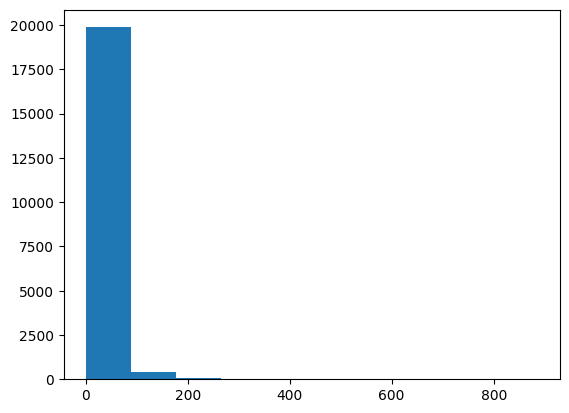

In [111]:
# plot distribution of degree list from giant component
plt.hist(giant_degrees)

linear histogram not looking great (big spike and then a tail). trying a log log histrogram

Text(0.5, 1.0, 'Degree distribution of HINT Giant Component')

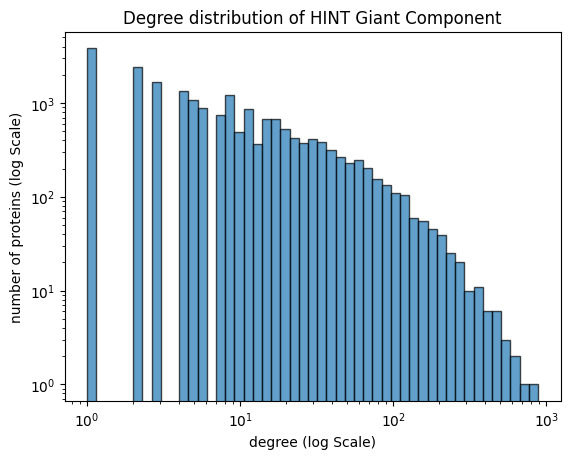

In [116]:
bins = np.logspace(np.log10(min(giant_degrees)), np.log10(max(giant_degrees)), num=50)

plt.hist(giant_degrees, bins=bins, edgecolor='black', alpha=0.7)

# log scales to both axes
plt.xscale('log')
plt.yscale('log')

plt.xlabel('degree (log Scale)')
plt.ylabel('number of proteins (log Scale)')
plt.title('Degree distribution of HINT Giant Component')

find hub proteins (not just shape), do this by sorting degree pairs by degree values, and look for top 10-20 to find bigger hubs along with tp53.

look for summary stats along with histogram like mean and median degree

**Clustering coefficient and betweeness centrality**